In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

In [2]:
df = pd.read_csv("spam_mail_classifier.csv")

print(df.head())
print(df.shape)
print(df.columns)

                                       email_text label
0              Let's catch up sometime next week!   ham
1  Don't forget to submit your project by Friday.   ham
2            Win a free iPhone now!!! Click here.  spam
3     Can you send me the report when it's ready?   ham
4    Meeting has been rescheduled to next Monday.   ham
(1000, 2)
Index(['email_text', 'label'], dtype='object')


In [3]:
print(df["label"].value_counts())

label
ham     583
spam    417
Name: count, dtype: int64


In [4]:
X = df["email_text"]
y = df["label"]

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 800
Testing samples: 200


In [6]:
vectorizer = TfidfVectorizer(
    lowercase=True,
    stop_words="english"
)

X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

print("Training TF-IDF shape:", X_train_tfidf.shape)
print("Testing TF-IDF shape:", X_test_tfidf.shape)

Training TF-IDF shape: (800, 39)
Testing TF-IDF shape: (200, 39)


In [7]:
model = SVC(
    kernel="linear",
    random_state=42
)

model.fit(X_train_tfidf, y_train)

,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'linear'
,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo random number generation for shuffling the data forprobability estimates. Ignored when `probability` is False.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",42
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide <shrinking_svm>`.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide <scores_probabilities>`...deprecated:: 1.9 The `probability` parameter is deprecated and will be removed in 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`.",'deprecated'
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None


In [8]:
y_pred = model.predict(X_test_tfidf)

print(y_pred)

['spam' 'ham' 'ham' 'spam' 'spam' 'ham' 'spam' 'ham' 'ham' 'ham' 'spam'
 'ham' 'ham' 'spam' 'spam' 'spam' 'spam' 'ham' 'ham' 'spam' 'spam' 'ham'
 'spam' 'ham' 'spam' 'ham' 'ham' 'ham' 'ham' 'ham' 'ham' 'ham' 'ham'
 'spam' 'ham' 'ham' 'ham' 'spam' 'spam' 'spam' 'ham' 'spam' 'spam' 'ham'
 'spam' 'ham' 'spam' 'ham' 'spam' 'spam' 'spam' 'spam' 'spam' 'ham' 'spam'
 'ham' 'ham' 'ham' 'ham' 'ham' 'spam' 'ham' 'ham' 'spam' 'spam' 'spam'
 'ham' 'ham' 'ham' 'ham' 'ham' 'ham' 'ham' 'ham' 'ham' 'spam' 'spam'
 'spam' 'spam' 'ham' 'ham' 'ham' 'spam' 'spam' 'ham' 'ham' 'ham' 'spam'
 'spam' 'ham' 'spam' 'ham' 'spam' 'spam' 'ham' 'ham' 'spam' 'ham' 'ham'
 'spam' 'spam' 'spam' 'spam' 'spam' 'spam' 'spam' 'ham' 'ham' 'spam' 'ham'
 'ham' 'ham' 'ham' 'ham' 'spam' 'spam' 'spam' 'spam' 'ham' 'ham' 'ham'
 'spam' 'ham' 'ham' 'ham' 'ham' 'spam' 'spam' 'ham' 'ham' 'spam' 'spam'
 'ham' 'ham' 'spam' 'ham' 'ham' 'spam' 'ham' 'ham' 'ham' 'ham' 'spam'
 'ham' 'ham' 'ham' 'spam' 'ham' 'ham' 'ham' 'ham' 'ham' 'spam' 'sp

In [9]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)
print("Accuracy (%):", accuracy * 100)

Accuracy: 1.0
Accuracy (%): 100.0


In [10]:
cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[117   0]
 [  0  83]]


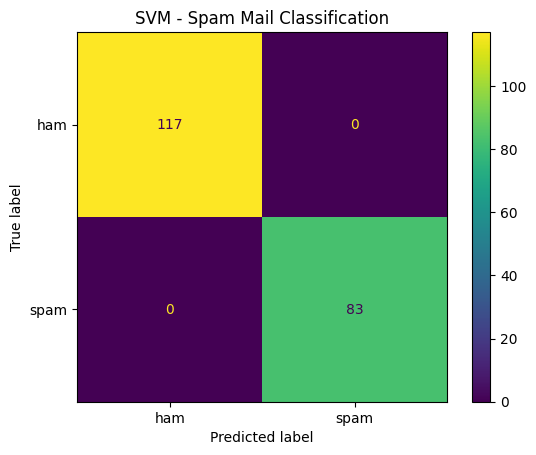

In [11]:
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=model.classes_
)

disp.plot()
plt.title("SVM - Spam Mail Classification")
plt.show()

In [12]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

         ham       1.00      1.00      1.00       117
        spam       1.00      1.00      1.00        83

    accuracy                           1.00       200
   macro avg       1.00      1.00      1.00       200
weighted avg       1.00      1.00      1.00       200



In [13]:
new_email = [
    "Congratulations! You have won a free iPhone. Click here to claim your prize."
]

new_email_tfidf = vectorizer.transform(new_email)

prediction = model.predict(new_email_tfidf)

print("Email:", new_email[0])
print("Predicted Label:", prediction[0])

Email: Congratulations! You have won a free iPhone. Click here to claim your prize.
Predicted Label: spam


In [14]:
new_email = [
    "Please send me the project report before tomorrow's meeting."
]

new_email_tfidf = vectorizer.transform(new_email)

prediction = model.predict(new_email_tfidf)

print("Predicted Label:", prediction[0])

Predicted Label: ham
